In [154]:
# A routing agent is use to route the request to the different agents.
# This kind of agent is very important in a multi-agent architecture.

In [155]:
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field
from langchain_core.messages import HumanMessage, BaseMessage, AIMessage, SystemMessage
from langchain.agents import create_agent

from langgraph.graph import StateGraph, START, END, add_messages

from typing import Literal, Annotated

from rich import print


import os


In [156]:
load_dotenv()
openai_key = os.getenv("OPENAI_KEY")

In [157]:
from typing import TypedDict


class AgentConfig(TypedDict):
    system_prompt:str
    tools = list[str]
    middlewares =list [str]

In [158]:
class State(BaseModel):
    user_query:str
    total_calls:int = Field(description ="total number of times for which the agent is called", default =0)
    request_type:str | None = None
    messages : Annotated[list[BaseMessage], add_messages]
    agent_config : AgentConfig | None = None

In [159]:
llm = ChatOpenAI(
    model="gpt-4.1-mini",
    temperature =0,
    api_key = openai_key
)

In [160]:
class RouteDecision(BaseModel):
    route : Literal["coding", "sql", "research", "general"] = Field(description= "Tells regarding the best specialist for the asked question.")

router = llm.with_structured_output(RouteDecision)

In [161]:
# defining the functions

def route_agent(state:State):

    system_message = """
    You are a routing agent whose job is to identify
    the user's request and route it to the correct agent.

    Routing options:
    ["coding", "sql", "research", "general"]
    """

    user_query = state.user_query

    messages = [
        SystemMessage(content=system_message),
        HumanMessage(content=user_query)
    ]

    response = router.invoke(messages)
    print("Route Response", response)

    return {
        "request_type": response.route
    }

In [162]:
config_obj = {
                "system_prompt":""
            }

In [163]:
def defining_the_agent_config(state: State):

    request_type = state.request_type

    if request_type == "coding":
        system_prompt = """
        You are a helpful coding agent.
        Analyse the problem first, understand it well,
        and then produce the result.
        """

    elif request_type == "sql":
        system_prompt = """
        You are a helpful SQL agent.
        Analyse the problem first, understand it well,
        and then produce the result.
        """

    elif request_type == "research":
        system_prompt = """
        You are a helpful research agent.
        Analyse the problem first, understand it well,
        and then produce the result.
        """

    elif request_type == "general":
        system_prompt = """
        You are a helpful AI agent whose job is to answer
        general queries.
        Analyse the query first, understand it well,
        and then produce the result.
        """

    else:
        raise ValueError(f"Unsupported request type: {request_type}")

    return {
        "agent_config": AgentConfig(
            system_prompt=system_prompt
        )
    }

In [164]:
def execute(state:State):

    system_msg = state.agent_config["system_prompt"]
    user_query = state.user_query
    messages = state.messages

    messages=[
        HumanMessage(content=user_query)
    ]

    agent = create_agent(
        model =llm,
        system_prompt= system_msg
    )

    result = agent.invoke({
        "messages":messages
    })

    print(result)
    return {
        "messages":result["messages"]
    }

In [165]:
# graph 

In [166]:
graph = StateGraph(State)

In [167]:
graph.add_node("route_agent", route_agent)
graph.add_node("defining_the_agent_config", defining_the_agent_config)
graph.add_node("execute", execute)

In [168]:
graph.add_edge(START, "route_agent")
graph.add_edge("route_agent","defining_the_agent_config")
graph.add_edge("defining_the_agent_config", "execute")
graph.add_edge("execute", END)

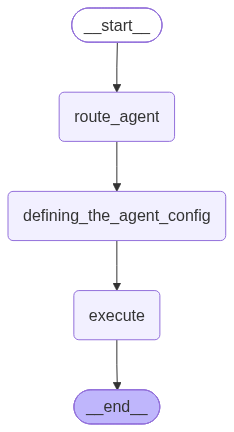

In [169]:
workflow= graph.compile()
workflow

In [174]:
initial_state ={
    "user_query":"Write a SQL query to create an employee table with minimum set of attributes and appropriate constrain"
}
result = workflow.invoke(initial_state)
print(result)
print(result["messages"][-1].content)

Route Response
RouteDecision(route='sql')

{
    'messages': [
        HumanMessage(
            content='Write a SQL query to create an employee table with minimum set of attributes and appropriate 
constrain',
            additional_kwargs={},
            response_metadata={},
            id='e240658b-8708-45a8-95b7-bb7eed7dc84a'
        ),
        AIMessage(
            content="To create an `employee` table with a minimum set of attributes and appropriate constraints, we
typically include:\n\n- `employee_id`: A unique identifier for each employee (Primary Key).\n- `first_name`: 
Employee's first name.\n- `last_name`: Employee's last name.\n- `email`: Employee's email address (should be 
unique).\n- `hire_date`: The date the employee was hired (cannot be null).\n\nHere is a SQL query to create such a 
table:\n\n```sql\nCREATE TABLE employee (\n    employee_id INT PRIMARY KEY,\n    first_name VARCHAR(50) NOT NULL,\n
last_name VARCHAR(50) NOT NULL,\n    email VARCHAR(100) UNIQUE NOT NULL,\n    hire_date DATE NOT 
NULL\n);\n```\n\nExplanation:\n- `employee_id` is the primary key to uniquely identify each employee.\n- 
`first_name` and `last_name` are required fields (`NOT NULL`).\n- `email` is unique and required.\n- `hire_date` is
required to track when the employee was hired.\n\nIf you want me to customize it further or add more attributes, 
please let me know!",
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 227,
                    'prompt_tokens': 55,
                    'total_tokens': 282,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 0,
                        'rejected_prediction_tokens': 0,
                        'text_tokens': None
                    },
                    'prompt_tokens_details': {
                        'audio_tokens': 0,
                        'cache_write_tokens': None,
                        'cached_tokens': 0,
                        'image_tokens': None,
                        'text_tokens': None
                    }
                },
                'model_provider': 'openai',
                'model_name': 'gpt-4.1-mini-2025-04-14',
                'system_fingerprint': 'fp_b5a057d79f',
                'id': 'chatcmpl-EFGhnfcrclaDYCXfThYzWh2cxAico',
                'service_tier': 'default',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--01a023d9-6020-7aa2-91ec-d1503aa15c8e-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 55,
                'output_tokens': 227,
                'total_tokens': 282,
                'input_token_details': {'audio': 0, 'cache_read': 0},
                'output_token_details': {'audio': 0, 'reasoning': 0}
            }
        )
    ]
}

{
    'user_query': 'Write a SQL query to create an employee table with minimum set of attributes and appropriate 
constrain',
    'request_type': 'sql',
    'messages': [
        HumanMessage(
            content='Write a SQL query to create an employee table with minimum set of attributes and appropriate 
constrain',
            additional_kwargs={},
            response_metadata={},
            id='e240658b-8708-45a8-95b7-bb7eed7dc84a'
        ),
        AIMessage(
            content="To create an `employee` table with a minimum set of attributes and appropriate constraints, we
typically include:\n\n- `employee_id`: A unique identifier for each employee (Primary Key).\n- `first_name`: 
Employee's first name.\n- `last_name`: Employee's last name.\n- `email`: Employee's email address (should be 
unique).\n- `hire_date`: The date the employee was hired (cannot be null).\n\nHere is a SQL query to create such a 
table:\n\n```sql\nCREATE TABLE employee (\n    employee_id INT PRIMARY KEY,\n    first_name VARCHAR(50) NOT NULL,\n
last_name VARCHAR(50) NOT NULL,\n    email VARCHAR(100) UNIQUE NOT NULL,\n    hire_date DATE NOT 
NULL\n);\n```\n\nExplanation:\n- `employee_id` is the primary key to uniquely identify each employee.\n- 
`first_name` and `last_name` are required fields (`NOT NULL`).\n- `email` is unique and required.\n- `hire_date` is
required to track when the employee was hired.\n\nIf you want me to customize it further or add more attributes, 
please let me know!",
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 227,
                    'prompt_tokens': 55,
                    'total_tokens': 282,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 0,
                        'rejected_prediction_tokens': 0,
                        'text_tokens': None
                    },
                    'prompt_tokens_details': {
                        'audio_tokens': 0,
                        'cache_write_tokens': None,
                        'cached_tokens': 0,
                        'image_tokens': None,
                        'text_tokens': None
                    }
                },
                'model_provider': 'openai',
                'model_name': 'gpt-4.1-mini-2025-04-14',
                'system_fingerprint': 'fp_b5a057d79f',
                'id': 'chatcmpl-EFGhnfcrclaDYCXfThYzWh2cxAico',
                'service_tier': 'default',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--01a023d9-6020-7aa2-91ec-d1503aa15c8e-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 55,
                'output_tokens': 227,
                'total_tokens': 282,
                'input_token_details': {'audio': 0, 'cache_read': 0},
                'output_token_details': {'audio': 0, 'reasoning': 0}
            }
        )
    ],
    'agent_config': {
        'system_prompt': '\n        You are a helpful SQL agent.\n        Analyse the problem first, understand it 
well,\n        and then produce the result.\n        '
    }
}

To create an `employee` table with a minimum set of attributes and appropriate constraints, we typically include:

- `employee_id`: A unique identifier for each employee (Primary Key).
- `first_name`: Employee's first name.
- `last_name`: Employee's last name.
- `email`: Employee's email address (should be unique).
- `hire_date`: The date the employee was hired (cannot be null).

Here is a SQL query to create such a table:

```sql
CREATE TABLE employee (
    employee_id INT PRIMARY KEY,
    first_name VARCHAR(50) NOT NULL,
    last_name VARCHAR(50) NOT NULL,
    email VARCHAR(100) UNIQUE NOT NULL,
    hire_date DATE NOT NULL
);
```

Explanation:
- `employee_id` is the primary key to uniquely identify each employee.
- `first_name` and `last_name` are required fields (`NOT NULL`).
- `email` is unique and required.
- `hire_date` is required to track when the employee was hired.

If you want me to customize it further or add more attributes, please let me know!